A logistics company wants to predict whether a shipment will be delayed or not before dispatch.

Delay_Status

Yes = Shipment Delayed
No = Shipment On Time

Since the target has only two categories (Yes/No), this is a Classification Problem, so we use Logistic Regression.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import(accuracy_score,confusion_matrix,classification_report)

In [2]:
df=pd.read_csv("/content/Shipment_Delay__md.csv")
df

,Shipment_ID,Booking_Date,Origin,Destination,Shipping_Line,Container_Type,Commodity,Weight_MT,Distance_KM,Fuel_Price,Transit_Days,Port_Congestion,Weather,Insurance_Cost,Handling_Charges,Exchange_Rate,Customer_Priority,Delay_Status,Freight_Cost
0,100001,2026-01-01,Mundra,Dubai,MSC,20FT,Cardamom,22.23,1004.0,100.61,10,Low,Rain,1985,1416.0,84.43,Normal,No,51969.2
1,100002,2026-01-02,Kandla,Colombo,Hapag-Lloyd,20FT,Cardamom,20.98,6665.0,99.05,20,Low,Clear,1169,313.0,87.79,Urgent,Yes,91877.0
2,100003,2026-01-03,Mundra,Bangkok,Hapag-Lloyd,40FT,Chilli,13.64,3912.0,89.64,14,Medium,Fog,2094,1240.0,86.68,Normal,No,65762.8
3,100004,2026-01-04,Chennai,Singapore,Hapag-Lloyd,40FT,Cardamom,23.27,1175.0,99.24,12,High,Fog,2374,506.0,85.90,Urgent,Yes,53845.8
4,100005,2026-01-05,Kolkata,Singapore,Hapag-Lloyd,20FT,Cardamom,23.23,6399.0,99.02,22,Medium,Clear,1101,634.0,86.31,Normal,Yes,92927.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1015,100134,2026-05-14,Chennai,Bangkok,Hapag-Lloyd,40FT,Black Pepper,20.93,2642.0,104.01,12,Medium,Rain,2013,1743.0,86.45,Urgent,No,65140.2
1016,100105,2026-04-15,Chennai,Singapore,Hapag-Lloyd,20FT,Black Pepper,21.85,1449.0,88.32,9,High,Clear,2089,1546.0,86.64,Normal,Yes,51400.4
1017,100007,2026-01-07,Kolkata,Rotterdam,MSC,20FT,Black Pepper,23.92,5215.0,92.47,21,Low,Clear,1341,749.0,88.99,Normal,Yes,82567.4
1018,100601,2026-08-24,Nhava Sheva,Dubai,Hapag-Lloyd,20FT,Turmeric,27.22,6955.0,101.86,14,Low,Rain,2381,1273.0,86.57,Normal,No,106423.2


In [3]:
df.head(20)

,Shipment_ID,Booking_Date,Origin,Destination,Shipping_Line,Container_Type,Commodity,Weight_MT,Distance_KM,Fuel_Price,Transit_Days,Port_Congestion,Weather,Insurance_Cost,Handling_Charges,Exchange_Rate,Customer_Priority,Delay_Status,Freight_Cost
0,100001,2026-01-01,Mundra,Dubai,MSC,20FT,Cardamom,22.23,1004.0,100.61,10,Low,Rain,1985,1416.0,84.43,Normal,No,51969.2
1,100002,2026-01-02,Kandla,Colombo,Hapag-Lloyd,20FT,Cardamom,20.98,6665.0,99.05,20,Low,Clear,1169,313.0,87.79,Urgent,Yes,91877.0
2,100003,2026-01-03,Mundra,Bangkok,Hapag-Lloyd,40FT,Chilli,13.64,3912.0,89.64,14,Medium,Fog,2094,1240.0,86.68,Normal,No,65762.8
3,100004,2026-01-04,Chennai,Singapore,Hapag-Lloyd,40FT,Cardamom,23.27,1175.0,99.24,12,High,Fog,2374,506.0,85.90,Urgent,Yes,53845.8
4,100005,2026-01-05,Kolkata,Singapore,Hapag-Lloyd,20FT,Cardamom,23.23,6399.0,99.02,22,Medium,Clear,1101,634.0,86.31,Normal,Yes,92927.4
5,100006,2026-01-06,Kandla,Rotterdam,Maersk,40FT,Cardamom,24.88,4086.0,92.55,9,High,Clear,2070,944.0,85.06,Normal,Yes,78289.0
6,100007,2026-01-07,Kolkata,Rotterdam,MSC,20FT,Black Pepper,23.92,5215.0,92.47,21,Low,Clear,1341,749.0,88.99,Normal,Yes,82567.4
7,100008,2026-01-08,Mundra,Dubai,CMA CGM,40FT,Turmeric,22.04,6374.0,95.18,5,Low,Clear,1558,1383.0,85.26,Normal,No,94722.6
8,100009,2026-01-09,Kolkata,Bangkok,Maersk,20FT,Turmeric,16.70,2095.0,95.71,11,High,Rain,1639,517.0,88.35,Normal,Yes,52875.2
9,100010,2026-01-10,Kolkata,Dubai,MSC,40FT,Black Pepper,20.63,5144.0,103.61,22,Low,Clear,1343,929.0,85.20,Normal,Yes,81397.2


In [4]:
df.tail(20)

,Shipment_ID,Booking_Date,Origin,Destination,Shipping_Line,Container_Type,Commodity,Weight_MT,Distance_KM,Fuel_Price,Transit_Days,Port_Congestion,Weather,Insurance_Cost,Handling_Charges,Exchange_Rate,Customer_Priority,Delay_Status,Freight_Cost
1000,100508,2026-05-23,Kandla,Rotterdam,Hapag-Lloyd,40FT,Cardamom,21.40,6411.0,93.77,22,High,Rain,1559,568.0,88.42,Normal,Yes,94849.4
1001,100819,2026-03-30,Chennai,Dubai,ONE,40FT,Cardamom,15.78,2465.0,95.42,10,Low,Clear,2188,1066.0,84.02,Urgent,No,54931.4
1002,100453,2026-03-29,Mundra,Dubai,CMA CGM,20FT,Chilli,13.73,6204.0,96.73,4,Low,Storm,688,435.0,85.51,Normal,Yes,79803.6
1003,100369,2026-01-04,Chennai,Dubai,Maersk,20FT,Chilli,15.92,5283.0,92.73,23,Medium,Fog,700,678.0,84.74,Urgent,Yes,79448.6
1004,100243,2026-08-31,Mundra,Bangkok,ONE,40FT,Cardamom,22.25,3068.0,92.44,25,High,Rain,985,607.0,86.59,Normal,Yes,64221.8
1005,100930,2026-07-19,Mundra,Rotterdam,CMA CGM,40FT,Turmeric,NaN,1278.0,101.83,21,Low,Clear,1886,372.0,86.82,Urgent,Yes,41151.6
1006,100263,2026-09-20,Kolkata,Bangkok,Hapag-Lloyd,20FT,Cumin,19.15,1772.0,104.67,23,Low,Clear,673,1441.0,86.75,Urgent,Yes,51829.4
1007,100811,2026-03-22,Nhava Sheva,Singapore,Hapag-Lloyd,40FT,Cumin,16.97,3907.0,100.00,8,Low,Clear,1447,762.0,88.18,Urgent,No,67972.0
1008,100319,2026-11-15,Kandla,Dubai,MSC,20FT,Turmeric,18.10,3147.0,95.88,7,High,Rain,1290,1163.0,87.16,Normal,Yes,65106.6
1009,100050,2026-02-19,Chennai,Bangkok,ONE,40FT,Chilli,13.36,2833.0,90.01,16,Medium,Rain,1062,1370.0,85.90,Normal,No,56547.2


In [5]:
df.shape

(1020, 19)

In [6]:
df.columns

Index(['Shipment_ID', 'Booking_Date', 'Origin', 'Destination', 'Shipping_Line',
       'Container_Type', 'Commodity', 'Weight_MT', 'Distance_KM', 'Fuel_Price',
       'Transit_Days', 'Port_Congestion', 'Weather', 'Insurance_Cost',
       'Handling_Charges', 'Exchange_Rate', 'Customer_Priority',
       'Delay_Status', 'Freight_Cost'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Shipment_ID        1020 non-null   int64  
 1   Booking_Date       1020 non-null   object 
 2   Origin             1020 non-null   object 
 3   Destination        1020 non-null   object 
 4   Shipping_Line      1020 non-null   object 
 5   Container_Type     1020 non-null   object 
 6   Commodity          1020 non-null   object 
 7   Weight_MT          1009 non-null   float64
 8   Distance_KM        1010 non-null   float64
 9   Fuel_Price         1020 non-null   float64
 10  Transit_Days       1020 non-null   int64  
 11  Port_Congestion    1020 non-null   object 
 12  Weather            1010 non-null   object 
 13  Insurance_Cost     1020 non-null   int64  
 14  Handling_Charges   1010 non-null   float64
 15  Exchange_Rate      1020 non-null   float64
 16  Customer_Priority  1020 

In [8]:
df.describe()

,Shipment_ID,Weight_MT,Distance_KM,Fuel_Price,Transit_Days,Insurance_Cost,Handling_Charges,Exchange_Rate,Freight_Cost
count,1020.000000,1009.000000,1010.000000,1020.000000,1020.000000,1020.000000,1010.000000,1020.000000,1020.000000
mean,100499.496078,19.927621,4119.109901,96.444686,14.303922,1545.681373,1033.253465,86.586176,75395.730588
std,289.213164,4.541128,2105.915815,4.938177,6.675559,558.169639,435.578814,1.417539,31707.480739
min,100001.000000,12.030000,821.000000,88.010000,3.000000,601.000000,300.000000,84.000000,39036.400000
25%,100249.750000,15.920000,2487.250000,92.055000,8.000000,1036.750000,644.000000,85.410000,60090.550000
50%,100497.500000,19.970000,4015.000000,96.320000,14.000000,1558.500000,1049.000000,86.590000,72277.600000
75%,100750.250000,23.610000,5638.250000,100.830000,20.000000,2013.000000,1402.750000,87.772500,84543.800000
max,101000.000000,28.000000,20682.000000,105.000000,25.000000,2500.000000,1800.000000,89.000000,398553.600000


Check Missing Values

In [9]:
df.isnull().sum()

,0
Shipment_ID,0
Booking_Date,0
Origin,0
Destination,0
Shipping_Line,0
Container_Type,0
Commodity,0
Weight_MT,11
Distance_KM,10
Fuel_Price,0



Fill Missing Values

In [10]:
#Numerical Value
df['Weight_MT']=df['Weight_MT'].fillna(df['Weight_MT'].mean())
df['Distance_KM']=df['Distance_KM'].fillna(df['Distance_KM'].mean())
df['Handling_Charges']=df['Handling_Charges'].fillna(df['Handling_Charges'].mean())

In [11]:
#Categorical Column
df['Weather']=df['Weather'].fillna(df['Weather'].mode()[0])

In [12]:
df.duplicated().sum()

np.int64(19)

In [13]:
df=df.drop_duplicates()

Identify & Remove Outlier

In [14]:
from pandas.core.arrays import numeric
numerical_columns=df.select_dtypes(include=['int64','Float64']).columns
print('Numerical Columns:',numerical_columns)

Numerical Columns: Index(['Shipment_ID', 'Weight_MT', 'Distance_KM', 'Fuel_Price', 'Transit_Days',
       'Insurance_Cost', 'Handling_Charges', 'Exchange_Rate', 'Freight_Cost'],
      dtype='object')


In [15]:
# Remove Shipment_ID because it is an identifier
numerical_columns=numerical_columns.drop('Shipment_ID')
print('Numerical_Columns:',numerical_columns)

Numerical_Columns: Index(['Weight_MT', 'Distance_KM', 'Fuel_Price', 'Transit_Days',
       'Insurance_Cost', 'Handling_Charges', 'Exchange_Rate', 'Freight_Cost'],
      dtype='object')


Check Outliers in Every Numerical Column

In [16]:
for col in numerical_columns:
  q1=df[col].quantile(0.25)
  q3=df[col].quantile(0.75)

  IQR=q3-q1

  lower_limit=q1-1.5*IQR
  upper_limit=q3+1.5*IQR

  outliers=df[(df[col]<lower_limit)|(df[col]>upper_limit)]
  print(f"{col}")
  print(f"lowerlimit:{lower_limit}")
  print(f"upperlimit:{upper_limit}")
  print(f"Totaloutlier:{len(outliers)}")
  print("-"*50)


Weight_MT
lowerlimit:4.459999999999999
upperlimit:35.1
Totaloutlier:0
--------------------------------------------------
Distance_KM
lowerlimit:-2197.5
upperlimit:10326.5
Totaloutlier:10
--------------------------------------------------
Fuel_Price
lowerlimit:78.78000000000002
upperlimit:114.05999999999999
Totaloutlier:0
--------------------------------------------------
Transit_Days
lowerlimit:-10.0
upperlimit:38.0
Totaloutlier:0
--------------------------------------------------
Insurance_Cost
lowerlimit:-422.5
upperlimit:3469.5
Totaloutlier:0
--------------------------------------------------
Handling_Charges
lowerlimit:-488.0
upperlimit:2536.0
Totaloutlier:0
--------------------------------------------------
Exchange_Rate
lowerlimit:81.83000000000001
upperlimit:91.35
Totaloutlier:0
--------------------------------------------------
Freight_Cost
lowerlimit:23260.200000000004
upperlimit:121474.59999999999
Totaloutlier:15
--------------------------------------------------


Remove Outliers from All Numerical Column

In [17]:
for col in numerical_columns:
  q1=df[col].quantile(0.25)
  q3=df[col].quantile(0.75)

  IQR=q3-q1

  lower_limit=q1-1.5*IQR
  upper_limit=q3+1.5*IQR

  df=df[(df[col]>=lower_limit) &(df[col]<=upper_limit)]
  print("Dataset shape after removing outlier:")
  print(df.shape)

Dataset shape after removing outlier:
(1001, 19)
Dataset shape after removing outlier:
(991, 19)
Dataset shape after removing outlier:
(991, 19)
Dataset shape after removing outlier:
(991, 19)
Dataset shape after removing outlier:
(991, 19)
Dataset shape after removing outlier:
(991, 19)
Dataset shape after removing outlier:
(991, 19)
Dataset shape after removing outlier:
(986, 19)


Verify That No Outliers Remain

In [18]:
for col in numerical_columns:
  q1=df[col].quantile(0.25)
  q3=df[col].quantile(0.75)

  IQR=q3-q1

  lower_limit=q1-1.5*IQR
  upper_limit=q3+1.5*IQR

  outliers=df[(df[col]<lower_limit)|(df[col]>upper_limit)]
  print(f"{col}:{len(outliers)}outliers_remaining")

Weight_MT:0outliers_remaining
Distance_KM:0outliers_remaining
Fuel_Price:0outliers_remaining
Transit_Days:0outliers_remaining
Insurance_Cost:0outliers_remaining
Handling_Charges:0outliers_remaining
Exchange_Rate:0outliers_remaining
Freight_Cost:0outliers_remaining


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 986 entries, 0 to 999
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Shipment_ID        986 non-null    int64  
 1   Booking_Date       986 non-null    object 
 2   Origin             986 non-null    object 
 3   Destination        986 non-null    object 
 4   Shipping_Line      986 non-null    object 
 5   Container_Type     986 non-null    object 
 6   Commodity          986 non-null    object 
 7   Weight_MT          986 non-null    float64
 8   Distance_KM        986 non-null    float64
 9   Fuel_Price         986 non-null    float64
 10  Transit_Days       986 non-null    int64  
 11  Port_Congestion    986 non-null    object 
 12  Weather            986 non-null    object 
 13  Insurance_Cost     986 non-null    int64  
 14  Handling_Charges   986 non-null    float64
 15  Exchange_Rate      986 non-null    float64
 16  Customer_Priority  986 non-null

Exploratory Data Analysis (EDA)

In [20]:
#Shipment Delay Count
df['Delay_Status'].value_counts()

,count
Delay_Status,
Yes,542
No,444


In [21]:
#Shipping Line Analysis
df.groupby("Shipping_Line")['Delay_Status'].value_counts()

Shipping_Line  Delay_Status
CMA CGM        Yes             110
               No               91
Hapag-Lloyd    Yes             122
               No               75
MSC            Yes             108
               No               94
Maersk         Yes             100
               No               77
ONE            No              107
               Yes             102
Name: count, dtype: int64

In [22]:
#Weather Analysis
df.groupby('Weather')["Delay_Status"].value_counts()

Weather  Delay_Status
Clear    Yes             298
         No              287
Fog      No               52
         Yes              48
Rain     Yes             110
         No              105
Storm    Yes              86
Name: count, dtype: int64

In [23]:
#Port Congestion
df.groupby('Port_Congestion')["Delay_Status"].value_counts()


Port_Congestion  Delay_Status
High             Yes             176
Low              No              262
                 Yes             230
Medium           No              182
                 Yes             136
Name: count, dtype: int64

Data Visualization

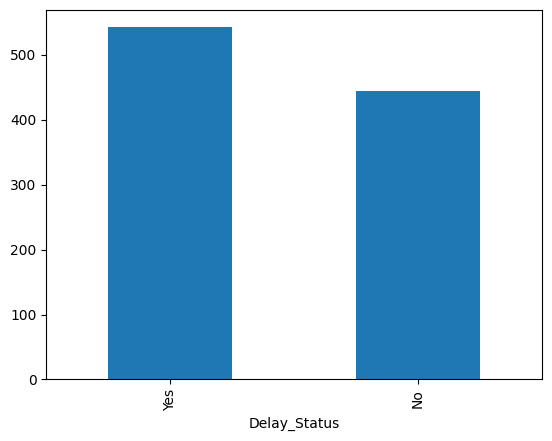

In [24]:
#Delay Distribution
df['Delay_Status'].value_counts().plot(kind="bar")
plt.show()

Freight Distribution

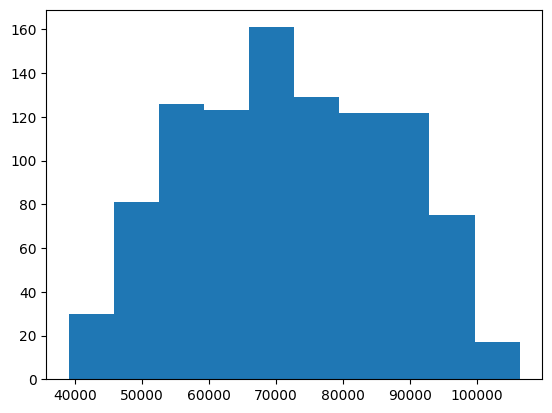

In [25]:
plt.hist(df["Freight_Cost"])
plt.show()

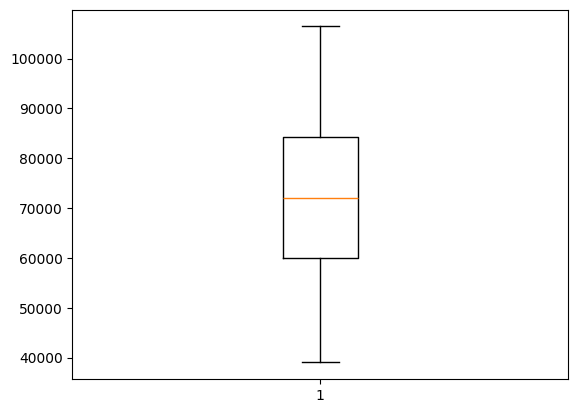

In [26]:
#Boxplot
plt.boxplot(df["Freight_Cost"])
plt.show()

In [27]:
#Feature Selection
x=df.drop(columns=[
"Shipment_ID","Booking_Date","Delay_Status"])
y=df['Delay_Status']

In [28]:
categorical=x.select_dtypes(include="object").columns

Column Transformer

In [29]:
preprocessor=ColumnTransformer(
[
(
 "cat",
 OneHotEncoder(handle_unknown="ignore"),
 categorical)],
 remainder="passthrough")

In [30]:
model=Pipeline([
("preprocessor",preprocessor),
("classifier",LogisticRegression(max_iter=1000))
])

In [31]:
#Train Test Split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)


Train Model

In [32]:
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppr

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Origin', 'Destination', 'Shipping_Line', 'Container_Type', 'Commodity',
       'Port_Congestion', 'Weather', 'Customer_Priority'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

Prediction

In [33]:
prediction=model.predict(x_test)
prediction

array(['No', 'Yes', 'No', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'No',
       'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No',
       'No', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'No',
       'No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No', 'No',
       'Yes', 'Yes', 'No', 'No', 'Yes', 'No', 'No', 'No', 'No', 'Yes',
       'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes',
       'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes',
       'Yes', 'No', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No',
       'Yes', 'No', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'No', 'No',
       'No', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'No', 'No', 'Yes',
       'No', 'No', 'No', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes',
       'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'No', 'No', 'No', 'No',
       'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No',
       'No', 'Yes', 'No', 'No', 'No', 'No', 'No', 'No',

Accuracy

In [34]:
Accuracy=accuracy_score(y_test,prediction)
print(Accuracy)

0.9141414141414141


Confusion Matrix

In [35]:
cm=confusion_matrix(y_test,prediction)
print(cm)

[[ 79  10]
 [  7 102]]


Classification Report

In [36]:
print(
classification_report(y_test,prediction))

              precision    recall  f1-score   support

          No       0.92      0.89      0.90        89
         Yes       0.91      0.94      0.92       109

    accuracy                           0.91       198
   macro avg       0.91      0.91      0.91       198
weighted avg       0.91      0.91      0.91       198



In [37]:
new_shipment = pd.DataFrame({

"Origin":["Mundra"],

"Destination":["Dubai"],

"Shipping_Line":["MSC"],

"Container_Type":["40FT"],

"Commodity":["Black Pepper"],

"Weight_MT":[24],

"Distance_KM":[1800],

"Fuel_Price":[96],

"Transit_Days":[8],

"Port_Congestion":["Low"],

"Weather":["Clear"],

"Insurance_Cost":[1200],

"Handling_Charges":[800],

"Exchange_Rate":[86],

"Customer_Priority":["Normal"],

"Freight_Cost":[52000]

})

In [38]:
prediction=model.predict(new_shipment)
print(prediction)

['No']


#Hence New shipment will arrive on time